<a href="https://colab.research.google.com/github/bigmackfridayfun789/CSCE1015/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
import networkx as nx
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print("Shape:", df.shape)
df.head()

df = pd.read_csv("bread_basket.csv")


print("Shape:", df.shape)
df.head()


Saving bread_basket.csv to bread_basket (5).csv
Shape: (20507, 6)
Shape: (20507, 6)


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [36]:
# write your answer here

df.dtypes



,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [32]:
# write your answer here


df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

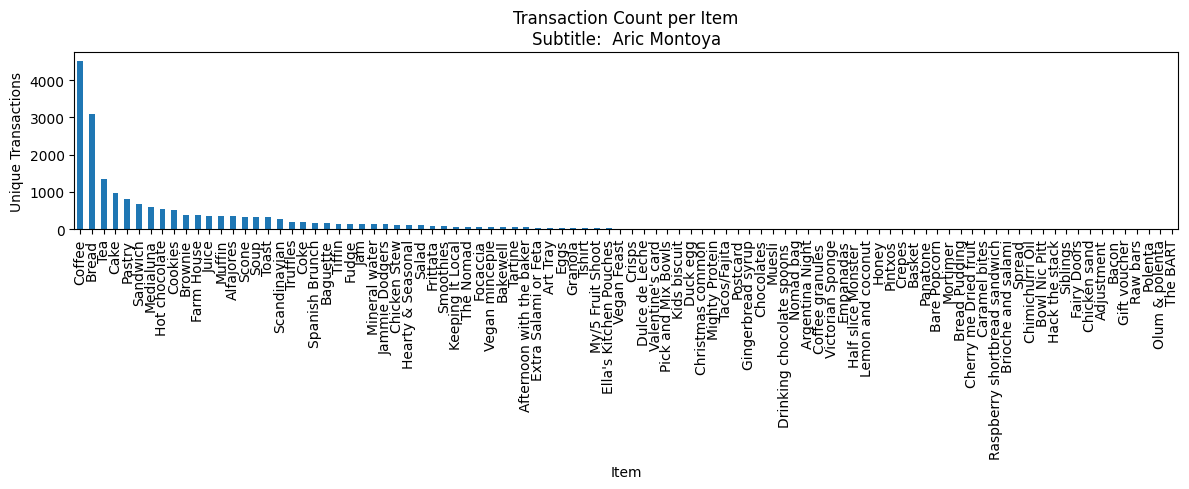

In [29]:
# c) Bar plot of transaction counts per item
subtitle = " Aric Montoya"  # <-- EDIT THIS
item_counts = (
    df.groupby("item")["transaction"]
      .nunique()
      .sort_values(ascending=False)
)
ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [28]:
# write your answer here

items_to_check = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

counts = (
    df[df["item"].isin(items_to_check)]
      .groupby("item")["transaction"]
      .nunique()
)

counts



,transaction
item,
Alfajores,344
Chicken Stew,123
Coffee,4528
Juice,365
Tea,1350


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [86]:
# write your answer here

basket = (
    df.groupby(['transaction', 'item'])
      .size()
      .unstack(fill_value=0)
)

basket = basket > 0
basket.head()



from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(
    basket,
    min_support=0.2,
    use_colnames=True
)

frequent_itemsets


,support,itemsets
0,0.327205,(Bread)
1,0.478394,(Coffee)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [85]:
# write your answer here
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1   # adjust as needed
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Coffee),(Bread),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634
1,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
2,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542
3,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707
4,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
5,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884
6,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
7,(Tea),(Coffee),0.142631,0.478394,0.049868,0.349630,0.730840,1.0,-0.018366,0.802014,-0.300482,0.087310,-0.246862,0.226935
8,(Coffee),(Tea),0.478394,0.142631,0.049868,0.104240,0.730840,1.0,-0.018366,0.957142,-0.413856,0.087310,-0.044777,0.226935
9,(Tea),(Bread),0.142631,0.327205,0.028104,0.197037,0.602181,1.0,-0.018566,0.837890,-0.435198,0.063621,-0.193474,0.141463


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* The rule {Coffee, Cake} ⇒ {Bread} means that shoppers who buy Coffee and Cake together often also buy Bread. Its support is the fraction of all transactions that contain all three items at the same time, its confidence is the share of Coffee‑and‑Cake baskets that also include Bread, and a lift greater than 1 shows that Bread appears with Coffee and Cake more often than expected by chance, indicating a meaningful positive association in customer buying behavior.


>